<a href="https://colab.research.google.com/github/gunaanand08/Ioe/blob/main/expreriment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== EDGE DEVICE ==========
Hour                : 24
Current Temperature : 5.8 °C
Records at Edge     : 24

========== CLOUD ==========
Cloud Records       : 24
Average Temperature : 5.92 °C
Moving Average      : 6.38 °C
Standard Deviation  : 2.71
Status              : NORMAL


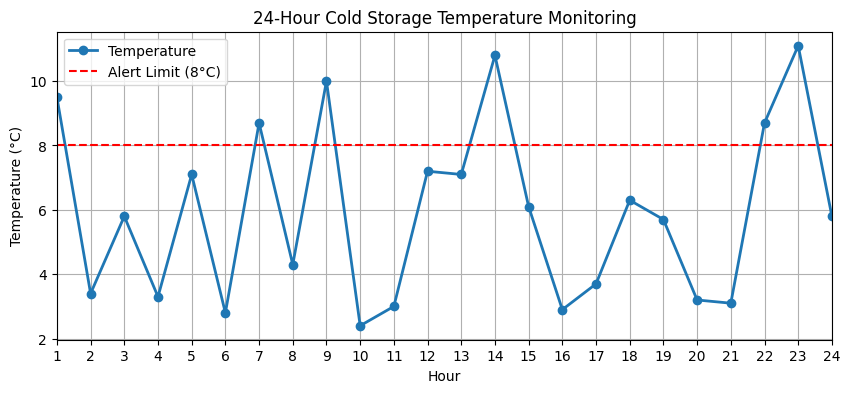


Experiment Completed Successfully!
Dataset saved as: 24hr_cold_storage_temperature.csv


In [3]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# -------------------------------
# Edge-Cloud Cold Storage Monitoring (24 Hours)
# -------------------------------

edge_storage = []
cloud_storage = []
hours = []

for hour in range(1, 25):

    # Generate realistic temperature
    if random.random() < 0.15:          # 15% chance of abnormal temperature
        temperature = round(random.uniform(8.5, 11.5), 1)
    else:
        temperature = round(random.uniform(2.0, 7.5), 1)

    # Edge Storage
    edge_storage.append(temperature)

    # Cloud Synchronization
    cloud_storage.append(temperature)

    hours.append(hour)

    # Analytics
    mean_temp = np.mean(cloud_storage)
    std_temp = np.std(cloud_storage)

    if len(cloud_storage) >= 5:
        moving_avg = np.mean(cloud_storage[-5:])
    else:
        moving_avg = mean_temp

    # Status
    if temperature > 8:
        status = "HIGH TEMPERATURE ALERT"
    else:
        status = "NORMAL"

    clear_output(wait=True)

    print("========== EDGE DEVICE ==========")
    print("Hour                :", hour)
    print("Current Temperature :", temperature, "°C")
    print("Records at Edge     :", len(edge_storage))

    print("\n========== CLOUD ==========")
    print("Cloud Records       :", len(cloud_storage))
    print("Average Temperature :", round(mean_temp, 2), "°C")
    print("Moving Average      :", round(moving_avg, 2), "°C")
    print("Standard Deviation  :", round(std_temp, 2))
    print("Status              :", status)

    # Plot
    plt.figure(figsize=(10,4))
    plt.plot(hours, cloud_storage,
             marker='o',
             linewidth=2,
             label='Temperature')

    plt.axhline(y=8,
                color='red',
                linestyle='--',
                label='Alert Limit (8°C)')

    plt.xticks(range(1, 25))
    plt.xlim(1, 24)

    plt.xlabel("Hour")
    plt.ylabel("Temperature (°C)")
    plt.title("24-Hour Cold Storage Temperature Monitoring")
    plt.legend()
    plt.grid(True)

    plt.show()

    # Delay (optional)
    time.sleep(0.5)

# Save Dataset
df = pd.DataFrame({
    "Hour": hours,
    "Temperature (°C)": cloud_storage
})

df.to_csv("24hr_cold_storage_temperature.csv", index=False)

print("\nExperiment Completed Successfully!")
print("Dataset saved as: 24hr_cold_storage_temperature.csv")